# Notebook 3 — Baseline Model Training & Evaluation

Notebooks 1 and 2 established what the data contains and prepared a modeling dataset. This notebook takes the next step: train several baseline regression models, compare them fairly, and choose one model to improve in Notebook 4.

---

# 1. Notebook Overview

### What are we predicting?

The target is `Expected_Retirement_Fund`, the projected value of a customer's retirement fund.

Notebook 1 showed that this target is strongly right-skewed. For that reason, the models are trained on `log(Expected_Retirement_Fund)`. Predictions are converted back to dollars when we report business-facing results.

### What data are we using?

Notebook 2 prepared:

- 23,880 training records
- 5,970 test records
- 40 modeling features

The features include numeric variables, five engineered numeric features, and 18 categorical indicator columns.

### Which models are we comparing?

Each model answers a different question:

| Model | Question |
|---|---|
| Median baseline | How much better can we do than predicting one number for everyone? |
| Linear Regression | How far can a simple linear relationship take us? |
| Ridge, Lasso, Elastic Net | Does regularization improve the linear model? |
| Random Forest | Does a non-linear tree model perform better? |
| Gradient Boosting | Does sequentially correcting tree errors perform better still? |

Notebook 1 found several non-linear relationships, especially for `Age` and the wealth variables. Notebook 3 tests whether those patterns actually improve prediction.

### Why start with baseline models?

The goal here is not to find the final model. It is to establish a reliable starting point.

We use sensible model settings, apply the same evaluation process, and avoid tuning. That gives Notebook 4 a clear benchmark against which improvements can be measured.

### How is the test set protected?

The 5,970 test records remain untouched until Section 13.

Sections 5–11 compare models on a validation split taken from the training data. Section 12 uses cross-validation within the training data. Only after the model is selected do we evaluate it on the test set.

### About the data

`retirement_dataset_v2.csv` is synthetic. The results are genuine outputs from running the models on this dataset, but they should not be interpreted as findings about real Canadian savers or as evidence that the model is ready for deployment.

---

# 2. Load the Prepared Data and Preprocessing Artifacts

### What are we doing?

We load the train/test splits, both target versions, and the two preprocessing pipelines created in Notebook 2.

### Why?

The preprocessing must be exactly the same throughout the project. Rebuilding it here could produce different imputation values, category encodings, or scaling statistics.

By loading the fitted pipelines and using `transform`, we apply the decisions already learned in Notebook 2 without learning them again from the test data.


In [1]:
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("pandas       ", pd.__version__)
print("numpy        ", np.__version__)
print("scikit-learn ", sklearn.__version__)

# Same visual identity as Notebooks 1 and 2.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E8E8E8",
    "font.size": 10,
})

NAVY = "#1F3B73"
TEAL = "#2A9D8F"
AMBER = "#E9A13B"
CORAL = "#E76F51"
SLATE = "#6C757D"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

pandas        3.0.2
numpy         2.4.4
scikit-learn  1.8.0


In [2]:
# The repository root is the folder that contains src/, so the notebook runs
# from either the root or notebooks/. On Colab, clone the repository first.
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/Retirement-Readiness-Predictor"),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "src" / "feature_engineering.py").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root (the folder containing src/). Checked: "
        + ", ".join(str(path) for path in CANDIDATE_ROOTS)
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /home/claude/Retirement-Readiness-Predictor


In [3]:
X_train_raw = pd.read_csv(ARTIFACTS_DIR / "X_train.csv.gz", index_col=0)
X_test_raw = pd.read_csv(ARTIFACTS_DIR / "X_test.csv.gz", index_col=0)

# Notebook 2 saved both versions of the target: the log values the models are
# trained on, and the dollar values used for business reporting.
y_train_all = pd.read_csv(ARTIFACTS_DIR / "y_train.csv", index_col=0)
y_test_all = pd.read_csv(ARTIFACTS_DIR / "y_test.csv", index_col=0)

y_train = y_train_all.log_target
y_test = y_test_all.log_target
y_test_dollars = y_test_all.target_dollars

preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
preprocessor_unscaled = joblib.load(ARTIFACTS_DIR / "preprocessor_unscaled.joblib")
feature_names = pd.read_csv(ARTIFACTS_DIR / "feature_names.csv").feature.tolist()

print(f"Training records: {len(X_train_raw):,}")
print(f"Test records:     {len(X_test_raw):,}")
print(f"Features:         {len(feature_names)}")

Training records: 23,880
Test records:     5,970
Features:         40


Both preprocessing pipelines were fitted using the training data in Notebook 2. Here we only transform the data, so nothing is relearned.

We keep two versions of the feature matrix:

- **Scaled features** for the linear models.
- **Unscaled features** for the tree models, because tree splits do not depend on feature scale.

### Result

Both versions contain the expected 40 features in the same order. This means the models can be compared without any feature-alignment problem.

### The validation split

Sections 5–11 need data on which to compare models without touching the final test set. We therefore split the 23,880 training records again:

- **80%** for fitting the models
- **20%** for validation

The 5,970 test records remain sealed until Section 13.

There is one limitation to this first comparison: the preprocessing statistics were learned from all 23,880 training records before this second split. Therefore, the validation rows contributed to the imputation and scaling values. The validation results are slightly optimistic.

Section 12 addresses this more strictly by refitting the complete preprocessing pipeline inside every cross-validation fold. The model choice is based on that cross-validation evidence.


In [4]:
X_train_scaled = preprocessor.transform(X_train_raw)
X_test_scaled = preprocessor.transform(X_test_raw)

X_train_tree = preprocessor_unscaled.transform(X_train_raw)
X_test_tree = preprocessor_unscaled.transform(X_test_raw)

print(f"X_train_scaled {X_train_scaled.shape}    X_test_scaled {X_test_scaled.shape}")
print(f"X_train_tree   {X_train_tree.shape}    X_test_tree   {X_test_tree.shape}")
print()
print("Train and test columns identical:",
      list(X_train_scaled.columns) == list(X_test_scaled.columns))
print("Columns match the saved feature list:",
      list(X_train_scaled.columns) == feature_names)
print("Scaled and unscaled columns identical:",
      list(X_train_scaled.columns) == list(X_train_tree.columns))
print("Missing values remaining:",
      int(X_train_scaled.isna().sum().sum() + X_test_scaled.isna().sum().sum()))

X_train_scaled (23880, 40)    X_test_scaled (5970, 40)
X_train_tree   (23880, 40)    X_test_tree   (5970, 40)

Train and test columns identical: True
Columns match the saved feature list: True
Scaled and unscaled columns identical: True
Missing values remaining: 0


### Result

Both matrices contain the expected 40 features, and their column order is identical. The model comparison can therefore use the same underlying feature set without any alignment problems.

### The validation split

Sections 5–11 need a place to compare models without using the final test set. We split the 23,880 training records again:

- **80%** for fitting
- **20%** for validation

The 5,970 test records stay sealed until Section 13.

There is one limitation to this first comparison. The preprocessing statistics were learned from all 23,880 training records before this second split, so the validation rows contributed to the medians and scaling values. The validation scores are therefore slightly optimistic.

Section 12 gives us the stricter comparison: the complete preprocessing pipeline is refitted inside every fold before that fold is scored.


In [5]:
X_fit_scaled, X_val_scaled, y_fit, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

# The tree matrix is indexed by the same customers, so the split is reused
# rather than recomputed.
X_fit_tree = X_train_tree.loc[X_fit_scaled.index]
X_val_tree = X_train_tree.loc[X_val_scaled.index]

print(f"Fit:        {X_fit_scaled.shape[0]:,} records")
print(f"Validation: {X_val_scaled.shape[0]:,} records")
print(f"Test (untouched until Section 13): {X_test_scaled.shape[0]:,} records")
print("Same customers in both representations:",
      X_fit_scaled.index.equals(X_fit_tree.index))

Fit:        19,104 records
Validation: 4,776 records
Test (untouched until Section 13): 5,970 records
Same customers in both representations: True


---

# 3. Define the Evaluation Strategy

### What are we doing?

Before training any model, we define the metrics and the rule used to compare models. This keeps the comparison consistent and prevents us from choosing a model after seeing whichever metric looks most favorable.

### Two ways of measuring error

The models are trained on `log(Expected_Retirement_Fund)`, so we evaluate performance in both **log space** and **dollar space**.

#### Log-space metrics

Log space is the scale used for training. It reduces the influence of very large retirement funds and makes relative differences more comparable across customers.

- **RMSE (&#36; in dollars, but log-space RMSE is reported without a dollar unit):** square-root of the mean squared error. Large mistakes receive more weight.
- **MAE (log):** average absolute error in log space. It is less sensitive to a few extreme mistakes than RMSE.
- **R²:** the proportion of variation in the log target explained by the model relative to a simple reference.

#### Dollar-space metrics

Predictions are converted back using `exp()` so that performance can also be understood in financial terms.

- **RMSE (&#36;):** dollar error with extra weight on large mistakes.
- **MAE (&#36;):** average absolute dollar error.
- **MAPE (%):** average absolute error as a percentage of each customer's actual retirement fund.

MAPE is useful here because the target is strictly positive and the smallest projected fund is about &#36;57K. The denominator therefore does not approach zero. Because MAPE is a mean, a small number of large percentage errors can pull it upward; Section 16 also reports the median absolute percentage error.

### A note about the back-transform

Exponentiating a log-space prediction gives a median-centred dollar estimate under the usual log-normal interpretation of the errors. It does not directly recover the conditional mean.

That matters when predictions are added across many customers: the total can be lower than the actual total. Section 15 measures this effect in this dataset.

### How will we choose the model?

**Dollar RMSE is the primary selection metric.**

The business impact of a large retirement-fund error is naturally expressed in dollars. R² is still reported, but it does not decide the ranking by itself.

If two models are effectively tied on dollar RMSE, the simpler and faster model is preferred.


In [6]:
def evaluate(model_name, y_true_log, y_pred_log):
    """Score one model in log space and in dollars, and print the result."""
    y_true_dollars = np.exp(y_true_log)
    y_pred_dollars = np.exp(y_pred_log)

    scores = {
        "Model": model_name,
        "R2": r2_score(y_true_log, y_pred_log),
        "RMSE (log)": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE (log)": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE ($)": np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars)),
        "MAE ($)": mean_absolute_error(y_true_dollars, y_pred_dollars),
        "MAPE (%)": np.mean(np.abs((y_true_dollars - y_pred_dollars) / y_true_dollars)) * 100,
    }

    print(f"{model_name}")
    print(f"   R2          {scores['R2']:>12.4f}")
    print(f"   RMSE (log)  {scores['RMSE (log)']:>12.4f}")
    print(f"   MAE  (log)  {scores['MAE (log)']:>12.4f}")
    print(f"   RMSE ($)    {scores['RMSE ($)']:>12,.0f}")
    print(f"   MAE  ($)    {scores['MAE ($)']:>12,.0f}")
    print(f"   MAPE (%)    {scores['MAPE (%)']:>12.1f}")
    return scores


# MAPE is only safe when the target stays away from zero.
print(f"Smallest training target: ${np.exp(y_train).min():>12,.0f}")
print(f"Largest training target:  ${np.exp(y_train).max():>12,.0f}")

# Every model appends one row here; Section 11 turns it into the comparison table.
results = []

Smallest training target: $      57,489
Largest training target:  $  40,078,282


---

# 4. Establish a Naive Baseline

### What are we doing?

Before training a real model, we create the simplest possible prediction: the median projected retirement fund among the fitting records.

That same number is predicted for every validation customer.

### Why?

We need a reference point.

An RMSE of &#36;1.8M means little without knowing what a very simple approach can achieve. The baseline tells us how much predictive value the features and models add.

The median is used instead of the mean because the target is strongly right-skewed. Importantly, the baseline is calculated from the fitting data only; validation and test targets are not used.


In [7]:
median_fit_dollars = np.exp(y_fit).median()
baseline_prediction = np.full(len(y_val), np.log(median_fit_dollars))

print(f"Constant prediction: ${median_fit_dollars:,.0f}\n")
results.append(evaluate("Median baseline", y_val, baseline_prediction))

Constant prediction: $3,325,680

Median baseline
   R2               -0.0175
   RMSE (log)        0.8654
   MAE  (log)        0.6575
   RMSE ($)       3,181,034
   MAE  ($)       2,209,120
   MAPE (%)           117.2


### Result

The baseline predicts about **&#36;3.33M for every customer**.

Its average absolute dollar error is about **&#36;2.21M**, and its RMSE is **&#36;3.18M**.

This gives us the floor that the trained models need to beat. Any model that cannot improve substantially on this constant prediction is not adding enough useful information.

---

# 5. Linear Regression

### What are we doing?

We fit an ordinary Linear Regression model using the standardized features and `log(Expected_Retirement_Fund)` as the target.

The model assumes that the target can be represented as a weighted combination of the input features.

### Why start here?

Linear Regression is simple, fast, and easy to interpret. It gives us a benchmark before we move to more flexible models.

### Why use the log target?

Notebook 1 found that the raw target is strongly right-skewed. A few very large retirement funds would have a disproportionate influence if we trained directly on dollars.

Taking the logarithm reduces that effect and makes the model focus more on relative differences. For example, a similar percentage error matters more similarly across a &#36;300K account and an &#36;8M account.

The model is intentionally simple. If it performs well, we may not need more complex algorithms. If it performs poorly, we have evidence that the relationship requires more flexibility.


In [8]:
linear_model = LinearRegression()
linear_model.fit(X_fit_scaled, y_fit)

results.append(evaluate("Linear Regression", y_val, linear_model.predict(X_val_scaled)))

Linear Regression
   R2                0.7755
   RMSE (log)        0.4065
   MAE  (log)        0.3038
   RMSE ($)       1,820,911
   MAE  ($)       1,108,265
   MAPE (%)            33.8


### Result

Linear Regression reaches **R² = 0.776** and reduces dollar RMSE from the &#36;3.18M baseline to about **&#36;1.82M**.

That is a **43% reduction in RMSE** compared with predicting the same median value for everyone.

This is a strong result for an untuned linear model. It confirms that the feature set contains substantial predictive information.

The next question is whether regularization can make this linear approach more stable or accurate.

---

# 6. Ridge Regression

### What are we doing?

Ridge is the same basic linear model, but it adds an L2 penalty that discourages very large coefficients.

### Why?

Several features share information by construction. For example, `YearsUntilRetirement` is related to `Age`, `RealExpectedReturn` is related to `ExpectedAnnualReturn`, and `SalaryBasedContribution` is based on `AnnualSalary`. Notebook 1 also found strong overlap between `Savings` and `InvestmentBalance`.

When predictors overlap, ordinary least squares can sometimes produce unstable coefficient estimates. Ridge pulls large coefficients toward zero, which can make the solution more stable.

`alpha=1.0` is the default Ridge penalty used here. Choosing the best penalty strength is a tuning question for Notebook 4.


In [9]:
# How much overlap is there? The strongest pairs are the engineered
# features and the columns they were built from.
correlations = X_train_scaled.corr().abs().unstack().sort_values(ascending=False)
correlations = correlations[correlations < 1].drop_duplicates()
print("Most correlated feature pairs in the training matrix:")
print(correlations.head(4).round(3).to_string(), "\n")

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_fit_scaled, y_fit)

results.append(evaluate("Ridge", y_val, ridge_model.predict(X_val_scaled)))

Most correlated feature pairs in the training matrix:
Age                 YearsUntilRetirement       0.972
RealExpectedReturn  ExpectedAnnualReturn       0.954
Savings             InvestmentBalance          0.916
AnnualSalary        SalaryBasedContribution    0.899 



Ridge


   R2                0.7755
   RMSE (log)        0.4065
   MAE  (log)        0.3038
   RMSE ($)       1,820,702
   MAE  ($)       1,108,215
   MAPE (%)            33.8


### Result

Ridge produces almost the same result as ordinary Linear Regression.

The dollar RMSE differs by only about **&#36;209** from Linear Regression, which is negligible compared with an error scale of about &#36;1.82M.

The correlated features identified in Notebook 1 are real, but they do not appear to be causing meaningful instability in this dataset. With 19,104 fitting records and 40 features, there is substantial information available to estimate the coefficients.

This does not mean Ridge is never useful. It means that **at this penalty strength and with this dataset**, regularization does not materially improve the baseline.

---

# 7. Lasso Regression

### What are we doing?

Lasso is another linear model, but it uses an L1 penalty. The penalty can shrink some coefficients all the way to zero.

A zero coefficient means that feature is effectively removed from the model.

### Why?

This lets us ask:

> Can we simplify the feature set without losing predictive performance?

That can be useful for interpretation and future feature selection.

Here `alpha=0.001` applies a mild penalty. A much larger value would be too aggressive for the scale of this log target and could push the model toward an almost constant prediction.


In [10]:
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_fit_scaled, y_fit)

results.append(evaluate("Lasso", y_val, lasso_model.predict(X_val_scaled)))

print(f"\nFeatures kept: {int((lasso_model.coef_ != 0).sum())} of {len(feature_names)}")

Lasso
   R2                0.7740
   RMSE (log)        0.4078
   MAE  (log)        0.3047
   RMSE ($)       1,808,324
   MAE  ($)       1,109,035
   MAPE (%)            33.9

Features kept: 33 of 40


### Result

Lasso removes **7 of the 40 features** while losing almost no predictive performance.

Its log-space RMSE is **0.4078**, compared with **0.4065** for Ridge, and its dollar RMSE remains within about **0.7%** of the other linear models.

This is useful evidence for feature selection, but it does not solve the main limitation of the linear family: the model is still restricted to linear relationships.

---

# 8. Elastic Net

### What are we doing?

Elastic Net combines the two regularization ideas:

- L1 regularization can remove features.
- L2 regularization keeps coefficients from becoming unnecessarily large.

### Why?

Lasso can behave unpredictably when several features carry similar information. Elastic Net is designed to handle that situation more smoothly by combining both penalties.

Here, `l1_ratio=0.5` gives equal weight to the two penalty types, with `alpha=0.001`.

This is another test of whether regularization can improve the linear family before we move to non-linear models.


In [11]:
elastic_net_model = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
elastic_net_model.fit(X_fit_scaled, y_fit)

results.append(evaluate("Elastic Net", y_val, elastic_net_model.predict(X_val_scaled)))

print(f"\nFeatures kept: {int((elastic_net_model.coef_ != 0).sum())} of {len(feature_names)}")

Elastic Net
   R2                0.7749
   RMSE (log)        0.4070
   MAE  (log)        0.3041
   RMSE ($)       1,812,068
   MAE  ($)       1,108,044
   MAPE (%)            33.8

Features kept: 35 of 40


### Result

Elastic Net performs almost exactly like the other linear models. All four linear approaches are within about **0.7%** of one another on dollar RMSE.

At the settings tested, regularization is therefore not the main lever for improvement. The larger limitation appears to be the linear form itself.

Different penalty strengths could change this conclusion, so that question is left for Notebook 4.

---

# 9. Random Forest Regressor

### What are we doing?

Random Forest builds many decision trees and combines their predictions.

Here, 300 trees are trained on different bootstrap samples, with random feature selection at each split. The final prediction is the average of the trees.

This allows the model to represent non-linear relationships and interactions that a linear equation cannot capture naturally.

### Why use the unscaled features?

Tree models split on thresholds within individual columns.

For example, a tree might ask:

> Is `Savings` greater than &#36;40,000?

Changing the scale of the column changes the numerical threshold but not the underlying split. Scaling therefore provides no predictive benefit for a tree model and makes the fitted thresholds harder to interpret.

### The parameters

These are baseline settings, not tuned values:

- `n_estimators=300` — enough trees for a reasonably stable ensemble.
- `min_samples_leaf=5` — prevents leaves from becoming too small and reduces the risk of memorizing individual customers.
- `max_depth=None` — leaves depth unconstrained while `min_samples_leaf` controls growth.
- `random_state=42` — keeps the result reproducible.
- `n_jobs=-1` — uses the available CPU cores.


In [12]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest.fit(X_fit_tree, y_fit)

results.append(evaluate("Random Forest", y_val, random_forest.predict(X_val_tree)))

Random Forest
   R2                0.8725
   RMSE (log)        0.3063
   MAE  (log)        0.2201
   RMSE ($)       1,413,716
   MAE  ($)         834,350
   MAPE (%)            22.9


### Result

Random Forest improves dollar RMSE from about **&#36;1.82M** for the best linear models to **&#36;1.41M**.

R² rises from about **0.776 to 0.873**, and MAPE falls from about **33.9% to 22.9%**.

The features and preprocessing have not changed. The important change is the model: trees can represent non-linear relationships and interactions.

This is the first strong predictive evidence that the non-linear structure identified in Notebook 1 matters.

---

# 10. Gradient Boosting Regressor

### What are we doing?

Gradient Boosting also uses decision trees, but it builds them **sequentially**.

The first trees make an initial prediction. Each following tree focuses on the remaining errors, and its contribution is added gradually using the learning rate.

Instead of averaging many independent trees, Gradient Boosting builds a sequence of corrections.

### Why compare it with Random Forest?

Both models can capture non-linear patterns, but they do it differently.

Random Forest builds trees independently and averages them. Gradient Boosting builds trees one after another, with each tree trying to improve the current model.

If Gradient Boosting performs better, that tells us the sequential correction process is capturing useful structure in this dataset.

### The parameters

These are baseline settings, not tuned values:

- `n_estimators=300` — builds 300 correction trees.
- `learning_rate=0.1` — controls how strongly each new tree changes the overall prediction.
- `max_depth=3` — keeps each tree shallow, so individual trees make smaller corrections.
- `random_state=42` — keeps the result reproducible.


In [13]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gradient_boosting.fit(X_fit_tree, y_fit)

results.append(evaluate("Gradient Boosting", y_val, gradient_boosting.predict(X_val_tree)))

Gradient Boosting
   R2                0.8877
   RMSE (log)        0.2874
   MAE  (log)        0.2035
   RMSE ($)       1,245,172
   MAE  ($)         757,712
   MAPE (%)            21.1


### Result

Gradient Boosting is the strongest model in the first comparison.

It reaches about **R² = 0.888** and **&#36;1.25M dollar RMSE** on the validation split.

That is about **12% better than Random Forest** and **31% better than the best linear model**.

The model achieves this with shallow depth-3 trees. That suggests it is capturing useful smooth non-linear structure rather than relying only on very deep interactions.

The next question is whether this advantage survives when we change the validation data.

---

# 11. Compare the Baseline Models

### What are we doing?

We collect the validation results from all models into one table and rank them by the metric chosen in Section 3.

### The selection rule

**Dollar RMSE is the primary ranking metric.**

It answers a practical question:

> How large are the model's mistakes when expressed in the actual currency of the problem?

R² remains useful as a complementary measure of explained variation, but it does not determine the ranking on its own.


In [14]:
comparison = pd.DataFrame(results).set_index("Model").sort_values("RMSE ($)")

baseline_rmse = comparison.loc["Median baseline", "RMSE ($)"]
comparison["vs baseline"] = (comparison["RMSE ($)"] / baseline_rmse - 1) * 100

# The headline comparisons, computed rather than read off the table by hand.
LINEAR_MODELS = ["Linear Regression", "Ridge", "Lasso", "Elastic Net"]
best_linear_rmse = comparison.loc[LINEAR_MODELS, "RMSE ($)"].min()
best_tree_rmse = comparison.loc["Gradient Boosting", "RMSE ($)"]

print(f"Spread across the four linear models: "
      f"{comparison.loc[LINEAR_MODELS, 'RMSE ($)'].max() / best_linear_rmse - 1:.1%}")
print(f"Gradient Boosting vs best linear model: {best_tree_rmse / best_linear_rmse - 1:+.1%}")
print(f"Gradient Boosting vs Random Forest:     "
      f"{best_tree_rmse / comparison.loc['Random Forest', 'RMSE ($)'] - 1:+.1%}")
print(f"Gradient Boosting vs median baseline:   {best_tree_rmse / baseline_rmse - 1:+.1%}\n")

comparison.style.format({
    "R2": "{:.4f}",
    "RMSE (log)": "{:.4f}",
    "MAE (log)": "{:.4f}",
    "RMSE ($)": "${:,.0f}",
    "MAE ($)": "${:,.0f}",
    "MAPE (%)": "{:.1f}%",
    "vs baseline": "{:+.1f}%",
})

Spread across the four linear models: 0.7%
Gradient Boosting vs best linear model: -31.1%
Gradient Boosting vs Random Forest:     -11.9%
Gradient Boosting vs median baseline:   -60.9%



,R2,RMSE (log),MAE (log),RMSE ($),MAE ($),MAPE (%),vs baseline
Model,,,,,,,
Gradient Boosting,0.8877,0.2874,0.2035,"$1,245,172","$757,712",21.1%,-60.9%
Random Forest,0.8725,0.3063,0.2201,"$1,413,716","$834,350",22.9%,-55.6%
Lasso,0.7740,0.4078,0.3047,"$1,808,324","$1,109,035",33.9%,-43.2%
Elastic Net,0.7749,0.4070,0.3041,"$1,812,068","$1,108,044",33.8%,-43.0%
Ridge,0.7755,0.4065,0.3038,"$1,820,702","$1,108,215",33.8%,-42.8%
Linear Regression,0.7755,0.4065,0.3038,"$1,820,911","$1,108,265",33.8%,-42.8%
Median baseline,-0.0175,0.8654,0.6575,"$3,181,034","$2,209,120",117.2%,+0.0%


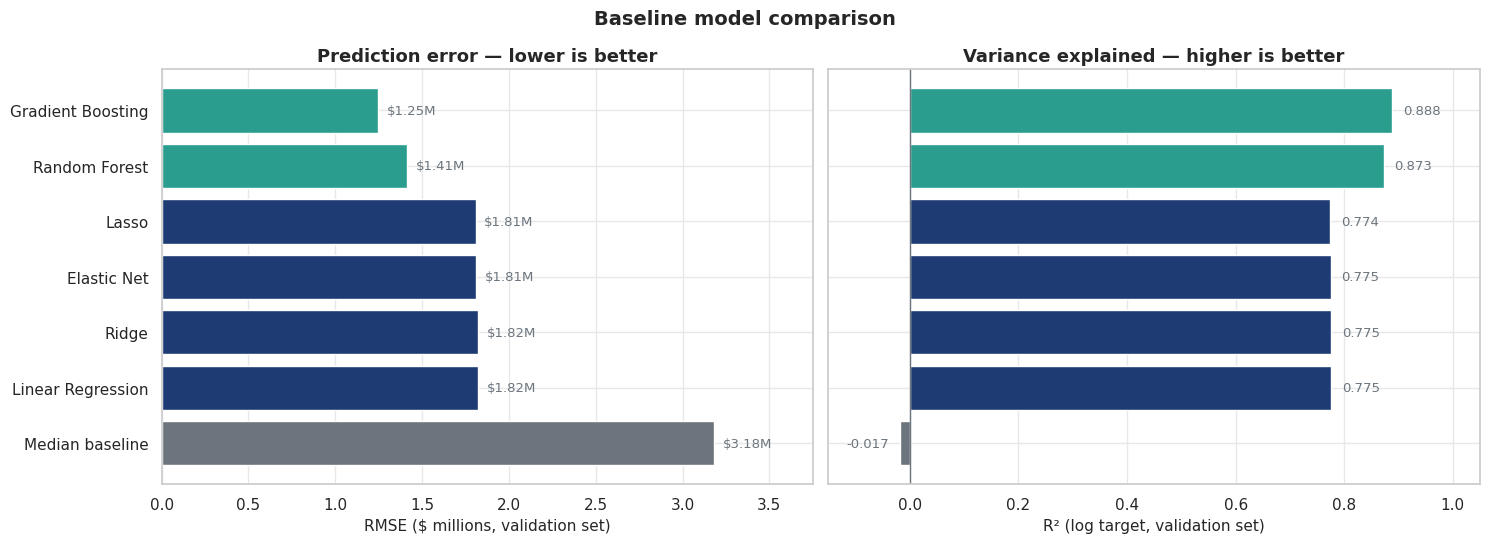

In [15]:
# --- Figure: how the models compare on the two headline metrics ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ordered = comparison.sort_values("RMSE ($)", ascending=False)
colours = []
for model_name in ordered.index:
    if model_name == "Median baseline":
        colours.append(SLATE)
    elif model_name in ("Random Forest", "Gradient Boosting"):
        colours.append(TEAL)
    else:
        colours.append(NAVY)

positions = np.arange(len(ordered))

axes[0].barh(positions, ordered["RMSE ($)"] / 1e6, color=colours, edgecolor="white")
axes[0].set_yticks(positions)
axes[0].set_yticklabels(ordered.index)
axes[0].set_xlabel("RMSE ($ millions, validation set)")
axes[0].set_title("Prediction error — lower is better")
for position, value in zip(positions, ordered["RMSE ($)"] / 1e6):
    axes[0].text(value + 0.05, position, f"${value:.2f}M", va="center", fontsize=9.5,
                 color=SLATE)
axes[0].set_xlim(0, ordered["RMSE ($)"].max() / 1e6 * 1.18)

axes[1].barh(positions, ordered["R2"], color=colours, edgecolor="white")
axes[1].set_yticks(positions)
axes[1].set_yticklabels([])
axes[1].set_xlabel("R² (log target, validation set)")
axes[1].set_title("Variance explained — higher is better")
axes[1].axvline(0, color=SLATE, lw=1)
for position, value in zip(positions, ordered["R2"]):
    offset = 0.02 if value >= 0 else -0.02
    alignment = "left" if value >= 0 else "right"
    axes[1].text(value + offset, position, f"{value:.3f}", va="center", ha=alignment,
                 fontsize=9.5, color=SLATE)
axes[1].set_xlim(-0.15, 1.05)

fig.suptitle("Baseline model comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_model_comparison.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

### Result

The models form three clear groups.

**The naive baseline** is at about **&#36;3.18M RMSE**. Every trained model beats it, showing that the features contain useful predictive information.

**The four linear models** cluster around **&#36;1.81–&#36;1.82M**. Ridge, Lasso, and Elastic Net are almost indistinguishable from ordinary Linear Regression at the settings tested.

**The tree ensembles** perform substantially better:

- Random Forest: about **&#36;1.41M**
- Gradient Boosting: about **&#36;1.25M**

Gradient Boosting leads on the validation metrics, and its roughly **31% lower RMSE** than the best linear model is much larger than the differences among the linear models.

This supports the EDA finding that non-linear relationships matter. But one validation split is not enough to be fully confident in the ranking. Section 12 checks whether the advantage survives across multiple folds.

---

# 12. Cross-Validation

### What are we doing?

The first model comparison used one validation split. Cross-validation checks whether the ranking remains stable when different customers are held out.

We use **five folds** and compare three representative models:

- **Ridge** — represents the linear family.
- **Random Forest** — represents one non-linear tree approach.
- **Gradient Boosting** — the strongest model from the first comparison.

### How does five-fold cross-validation work?

The training data is divided into five groups.

Each run uses four groups for training and the remaining group for validation. This is repeated five times so every group serves as the validation set once.

For each fold, the complete preprocessing pipeline is refitted on the fitting portion before the model is trained. The held-out fold therefore does not influence imputation, feature engineering, encoding, or scaling.

The test set remains completely separate.

### Why?

A single validation split can sometimes make a model look better simply because of which customers happened to fall into that split.

Cross-validation gives us five performance estimates instead of one. It lets us see both the average performance and how much that performance changes from fold to fold.


In [16]:
candidate_models = {
    "Ridge": Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", clone(preprocessor_unscaled)),
        ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", clone(preprocessor_unscaled)),
        ("model", GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                                            max_depth=3, random_state=RANDOM_STATE)),
    ]),
}

folds = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for model_name, pipeline in candidate_models.items():
    started = time.time()
    fold_rmse_log = []
    fold_rmse_dollars = []

    for train_index, validation_index in folds.split(X_train_raw):
        fitted = clone(pipeline).fit(
            X_train_raw.iloc[train_index], y_train.iloc[train_index]
        )
        predicted = fitted.predict(X_train_raw.iloc[validation_index])
        actual = y_train.iloc[validation_index]

        fold_rmse_log.append(np.sqrt(mean_squared_error(actual, predicted)))
        fold_rmse_dollars.append(
            np.sqrt(mean_squared_error(np.exp(actual), np.exp(predicted)))
        )

    cv_rows.append({
        "Model": model_name,
        "RMSE (log) mean": np.mean(fold_rmse_log),
        "RMSE (log) std": np.std(fold_rmse_log),
        "RMSE ($) mean": np.mean(fold_rmse_dollars),
        "RMSE ($) std": np.std(fold_rmse_dollars),
    })
    print(f"{model_name:<20} {time.time() - started:>6.0f}s")

cv_results = pd.DataFrame(cv_rows).set_index("Model")
cv_results.style.format({
    "RMSE (log) mean": "{:.4f}",
    "RMSE (log) std": "{:.4f}",
    "RMSE ($) mean": "${:,.0f}",
    "RMSE ($) std": "${:,.0f}",
})

Ridge                     1s


Random Forest           156s


Gradient Boosting       140s


,RMSE (log) mean,RMSE (log) std,RMSE ($) mean,RMSE ($) std
Model,,,,
Ridge,0.4056,0.0072,"$1,809,371","$62,708"
Random Forest,0.2964,0.0057,"$1,361,857","$42,200"
Gradient Boosting,0.2787,0.0078,"$1,239,045","$48,026"


### Result

The ranking remains clear across the five folds.

| Model | 5-fold CV RMSE |
|---|---:|
| Gradient Boosting | &#36;1.24M ± &#36;48K |
| Random Forest | &#36;1.36M ± &#36;42K |
| Ridge | &#36;1.81M ± &#36;63K |

The first number is the average RMSE across the five folds. The ± value is the standard deviation, showing how much the score changes from fold to fold.

Gradient Boosting's average advantage over Random Forest is about **&#36;123K**, which is larger than the fold-to-fold variation observed for either model. This supports a stable separation rather than a result driven by one unusually favorable split.

The cross-validation result is also close to the earlier validation result for Gradient Boosting: about **&#36;1.24M here versus &#36;1.25M in Section 11**.

Gradient Boosting is therefore selected as the baseline model.

---

# 13. Final Evaluation on the Test Set

### What are we doing?

Now that the model has been selected using training data only, we refit Gradient Boosting on **all 23,880 training records** and evaluate it once on the **5,970 untouched test records**.

### Why now?

The test set is our final check of generalization. It has not been used to compare models, tune parameters, or make the selection decision.

The final model is stored together with the preprocessing pipeline so that the same transformation can be applied to raw customer records later.


In [17]:
final_model = Pipeline([
    ("preprocess", clone(preprocessor_unscaled)),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
    )),
])
final_model.fit(X_train_raw, y_train)

test_predictions_log = final_model.predict(X_test_raw)
test_predictions_dollars = np.exp(test_predictions_log)

test_scores = evaluate("Gradient Boosting (test set)", y_test, test_predictions_log)

# R² in dollars answers a different question from R² in log space: how much of
# the variation in actual amounts the model reproduces.
print(f"\n   R2 in dollars {r2_score(y_test_dollars, test_predictions_dollars):>12.4f}")
print(f"   Median AE ($) {np.median(np.abs(test_predictions_dollars - y_test_dollars)):>12,.0f}")

stage_comparison = pd.DataFrame({
    "RMSE (log)": [
        comparison.loc["Gradient Boosting", "RMSE (log)"],
        cv_results.loc["Gradient Boosting", "RMSE (log) mean"],
        test_scores["RMSE (log)"],
    ],
    "RMSE ($)": [
        comparison.loc["Gradient Boosting", "RMSE ($)"],
        cv_results.loc["Gradient Boosting", "RMSE ($) mean"],
        test_scores["RMSE ($)"],
    ],
}, index=["Validation split (Section 11)",
          "5-fold cross-validation (Section 12)",
          "Test set (Section 13)"])

stage_comparison.style.format({"RMSE (log)": "{:.4f}", "RMSE ($)": "${:,.0f}"})

Gradient Boosting (test set)
   R2                0.8962
   RMSE (log)        0.2814
   MAE  (log)        0.2030
   RMSE ($)       1,266,265
   MAE  ($)         769,677
   MAPE (%)            21.3

   R2 in dollars       0.8429
   Median AE ($)      448,701


,RMSE (log),RMSE ($)
Validation split (Section 11),0.2874,"$1,245,172"
5-fold cross-validation (Section 12),0.2787,"$1,239,045"
Test set (Section 13),0.2814,"$1,266,265"


### Result

On the unseen test customers, Gradient Boosting reaches:

- **R² = 0.896** in log space
- **R² = 0.843** in dollars
- **RMSE ≈ &#36;1.27M**
- **MAE ≈ &#36;770K**
- **Median absolute error ≈ &#36;449K**
- **MAPE = 21.3%**

The three performance estimates are close:

| Evaluation | Dollar RMSE |
|---|---:|
| Validation split | &#36;1.25M |
| 5-fold cross-validation | &#36;1.24M |
| Final test set | &#36;1.27M |

The slightly higher test error is normal for a final holdout. The small difference between the three estimates suggests that the baseline generalizes consistently.

The median absolute error is much lower than the mean absolute error. This is consistent with a distribution where most customers have moderate errors while a smaller number of large accounts produce much larger dollar mistakes. Section 16 examines those errors by segment.

---

# 14. Prediction vs Actual

### What are we doing?

We plot the model's predicted retirement fund against the actual retirement fund for the test customers.

The diagonal line is a **perfect-prediction reference**:

> predicted value = actual value

It is not a regression line and it is not the Gradient Boosting model.

### Why use log scales?

The test targets range from about **&#36;64K to &#36;33M**. On a linear scale, most customers would be compressed near the bottom of the chart.

Log scales give smaller and larger accounts more comparable visual space. A random sample of about 2,000 customers is shown so individual points remain visible.

### How to read the figure

- Points close to the diagonal are accurate predictions.
- Points above the line are over-predictions.
- Points below the line are under-predictions.
- A widening cloud means prediction error is increasing in that part of the range.


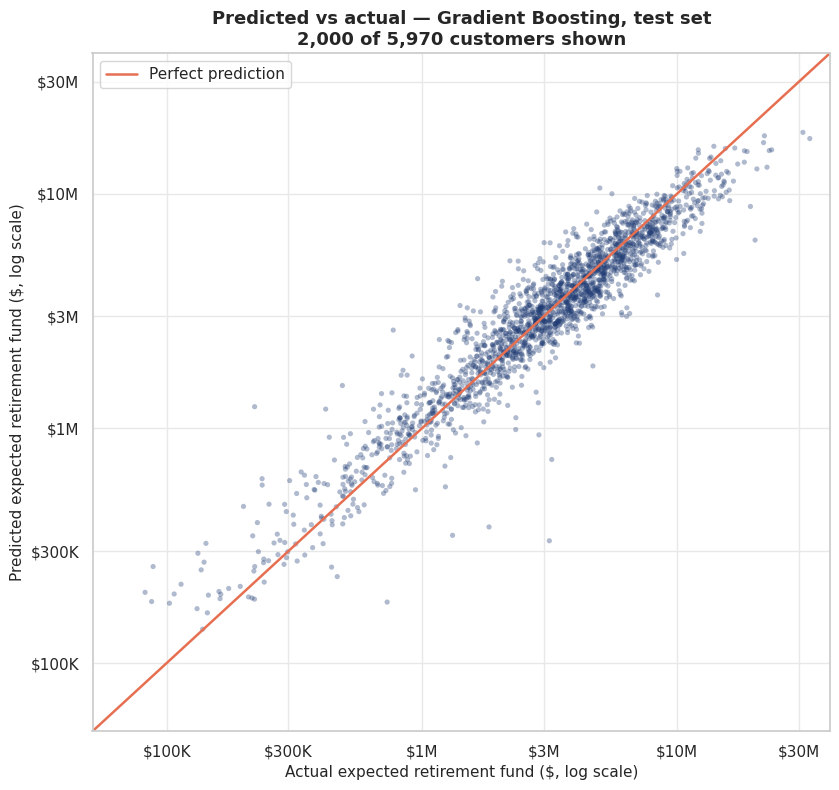

In [18]:
# --- Figure: predicted vs actual on the test set -------------------------
sample = pd.DataFrame({
    "actual": y_test_dollars.to_numpy(),
    "predicted": test_predictions_dollars,
}).sample(2000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8.5, 8))

ax.scatter(sample.actual, sample.predicted, s=14, alpha=0.35, color=NAVY,
           edgecolors="none")

limits = [y_test_dollars.min() * 0.8, y_test_dollars.max() * 1.2]
ax.plot(limits, limits, color=CORAL, lw=1.8, label="Perfect prediction")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("Actual expected retirement fund ($, log scale)")
ax.set_ylabel("Predicted expected retirement fund ($, log scale)")
ax.set_title("Predicted vs actual — Gradient Boosting, test set\n"
             f"2,000 of {len(y_test_dollars):,} customers shown")

tick_values = [1e5, 3e5, 1e6, 3e6, 1e7, 3e7]
tick_labels = ["$100K", "$300K", "$1M", "$3M", "$10M", "$30M"]
ax.set_xticks(tick_values)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_values)
ax.set_yticklabels(tick_labels)

ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_predicted_vs_actual.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

### Result

The points generally follow the diagonal across the full range, which is consistent with the strong overall performance.

The spread is not constant, however. Predictions for smaller projected funds are more widely dispersed, while the largest customers sit somewhat closer to the centre of the prediction range.

These patterns are easier to quantify with residuals, which is the purpose of Section 15.

---

# 15. Residual Analysis

### What are we doing?

A residual is:

**actual value − predicted value**

We examine residuals in log space and plot them against the predicted values.

### Why use residuals?

A prediction score tells us **how much error exists**. Residual analysis helps us understand **how that error is distributed**.

If residuals are randomly scattered around zero, that is encouraging. A visible pattern can indicate that the model behaves differently at different prediction levels.

### Why log space?

Dollar errors naturally become larger for customers with larger retirement funds. Plotting dollar residuals would therefore mix scale effects with model behaviour.

In log space, the residual is much closer to a relative error, making the pattern easier to compare across the range.


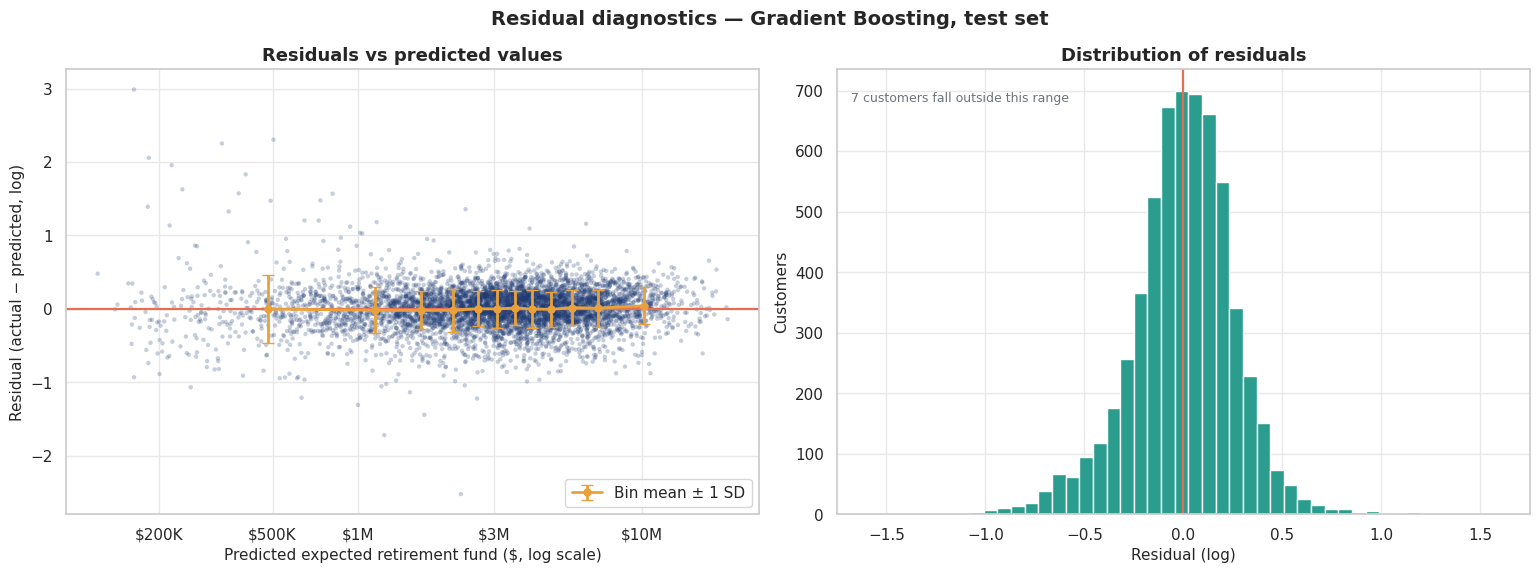

In [19]:
# --- Figure: residual diagnostics ----------------------------------------
residuals = y_test.to_numpy() - test_predictions_log

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

axes[0].scatter(test_predictions_log, residuals, s=10, alpha=0.25, color=NAVY,
                edgecolors="none")
axes[0].axhline(0, color=CORAL, lw=1.6)

# Binned means and spread, so the pattern is readable through the cloud.
bins = pd.qcut(test_predictions_log, 12, labels=False)
binned = pd.DataFrame({"prediction": test_predictions_log,
                       "residual": residuals,
                       "bin": bins}).groupby("bin").agg(
    centre=("prediction", "mean"),
    mean_residual=("residual", "mean"),
    spread=("residual", "std"),
)
axes[0].errorbar(binned.centre, binned.mean_residual, yerr=binned.spread,
                 color=AMBER, lw=2, marker="o", markersize=5, capsize=4,
                 label="Bin mean ± 1 SD")
axes[0].set_xticks(np.log([2e5, 5e5, 1e6, 3e6, 1e7]))
axes[0].set_xticklabels(["$200K", "$500K", "$1M", "$3M", "$10M"])
axes[0].set_xlabel("Predicted expected retirement fund ($, log scale)")
axes[0].set_ylabel("Residual (actual − predicted, log)")
axes[0].set_title("Residuals vs predicted values")
axes[0].legend(loc="lower right", frameon=True)

axes[1].hist(residuals, bins=80, color=TEAL, edgecolor="white")
axes[1].axvline(0, color=CORAL, lw=1.6)
axes[1].set_xlim(-1.75, 1.75)
axes[1].set_xlabel("Residual (log)")
axes[1].set_ylabel("Customers")
axes[1].set_title("Distribution of residuals")
axes[1].text(0.02, 0.95,
             f"{int((np.abs(residuals) > 1.75).sum())} customers fall outside this range",
             transform=axes[1].transAxes, fontsize=9, color=SLATE, va="top")

fig.suptitle("Residual diagnostics — Gradient Boosting, test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residuals.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

In [20]:
# Two things the plot suggests, measured rather than eyeballed.
quintile = pd.qcut(test_predictions_log, 5, labels=["1 (lowest)", "2", "3", "4", "5 (highest)"])
residual_by_quintile = pd.DataFrame({"residual": residuals}).groupby(quintile, observed=True).agg(
    customers=("residual", "size"),
    mean_residual=("residual", "mean"),
    sd_residual=("residual", "std"),
)
print("Residuals by predicted quintile (log space):")
print(residual_by_quintile.round(4).to_string())

dollar_error = test_predictions_dollars - y_test_dollars
print(f"\nMean actual    ${y_test_dollars.mean():>14,.0f}")
print(f"Mean predicted ${test_predictions_dollars.mean():>14,.0f}")
print(f"Aggregate shortfall {dollar_error.mean() / y_test_dollars.mean() * 100:>8.1f}%")

Residuals by predicted quintile (log space):
             customers  mean_residual  sd_residual
1 (lowest)        1194        -0.0141       0.3745
2                 1194        -0.0167       0.2679
3                 1194         0.0061       0.2460
4                 1194         0.0013       0.2478
5 (highest)       1194         0.0209       0.2477

Mean actual    $     4,062,102
Mean predicted $     3,895,124
Aggregate shortfall     -4.1%


### Result

The residuals are centred near zero and are broadly symmetric, but two patterns are worth measuring.

**The spread is wider for smaller predicted funds.** The residual standard deviation is **0.375** in the lowest predicted quintile, compared with **0.246–0.268** in the other four quintiles. The lowest group therefore has roughly 50% more residual variation.

**There is a small directional drift.** Mean residuals move from **−0.014** in the lowest quintile to **+0.021** in the highest. In practical terms, the model slightly overpredicts smaller accounts and slightly underpredicts larger accounts. The effect is small, and this analysis does not establish why it occurs.

There is also an important aggregate effect. The mean predicted fund is about **&#36;3.90M**, compared with **&#36;4.06M** for the actual test targets — roughly a **4% shortfall** when predictions are added together.

This happens because exponentiating a log-space prediction gives a median-centred estimate rather than directly recovering the conditional mean. For an individual customer the distinction may be modest, but across a portfolio it can matter.

Notebook 4 can test possible remedies, such as a smearing correction, a dollar-scale model, or a different objective.

---

# 16. Error Analysis

### What are we doing?

We break the test-set errors into two business-relevant groups:

- income quintile
- years until retirement

These are the same types of segmentation used in Notebook 1.

### Why?

An overall metric can hide meaningful differences between customer groups. A model may perform well on average while producing larger relative errors for a particular segment.

The income-quintile boundaries are calculated from training salaries, so the test data does not determine the segmentation.


In [21]:
errors = pd.DataFrame({
    "actual": y_test_dollars.to_numpy(),
    "predicted": test_predictions_dollars,
    "absolute_error": np.abs(dollar_error.to_numpy()),
    "signed_error": dollar_error.to_numpy(),
    "salary": X_test_tree.AnnualSalary.to_numpy(),
    "years_until_retirement": X_test_tree.YearsUntilRetirement.to_numpy(),
})
errors["percentage_error"] = errors.absolute_error / errors.actual * 100

salary_cuts = [-np.inf] + list(X_train_tree.AnnualSalary.quantile([0.2, 0.4, 0.6, 0.8])) + [np.inf]
errors["IncomeQuintile"] = pd.cut(
    errors.salary, bins=salary_cuts,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
)

# Same four bands Notebook 1 used for the retirement journey.
errors["HorizonBand"] = pd.cut(
    errors.years_until_retirement, bins=[0, 10, 20, 30, 50],
    labels=["1-10 yrs", "11-20 yrs", "21-30 yrs", "31+ yrs"],
)

print("Absolute error percentiles ($):")
for percentile in [50, 75, 90, 95, 99]:
    print(f"   p{percentile:<3} {np.percentile(errors.absolute_error, percentile):>12,.0f}")
# MAPE is a mean, so it sits above the middle of the distribution. The median
# is the better answer to "how far off is a typical customer?".
print(f"\nMean absolute percentage error:   {errors.percentage_error.mean():.1f}%")
print(f"Median absolute percentage error: {errors.percentage_error.median():.1f}%")
print(f"\nWithin 10% of the actual amount: {(errors.percentage_error <= 10).mean() * 100:.1f}%")
print(f"Within 25% of the actual amount: {(errors.percentage_error <= 25).mean() * 100:.1f}%")
print(f"Under-predicted:                 {(errors.signed_error < 0).mean() * 100:.1f}%")

Absolute error percentiles ($):
   p50       448,701
   p75       961,708
   p90     1,854,355
   p95     2,668,285
   p99     4,702,836

Mean absolute percentage error:   21.3%
Median absolute percentage error: 15.3%

Within 10% of the actual amount: 33.6%
Within 25% of the actual amount: 72.5%
Under-predicted:                 51.7%


In [22]:
def summarise_errors(group_column):
    """Error profile for one segmentation."""
    summary = errors.groupby(group_column, observed=True).agg(
        customers=("actual", "size"),
        median_actual=("actual", "median"),
        MAE=("absolute_error", "mean"),
        median_AE=("absolute_error", "median"),
        MAPE=("percentage_error", "mean"),
    )
    summary["pct_under"] = errors.groupby(group_column, observed=True).signed_error.apply(
        lambda values: (values < 0).mean() * 100
    )
    return summary


income_errors = summarise_errors("IncomeQuintile")
horizon_errors = summarise_errors("HorizonBand")

print("By income quintile")
print(income_errors.round(1).to_string())
print("\nBy retirement horizon")
print(horizon_errors.round(1).to_string())

By income quintile
                customers  median_actual        MAE  median_AE  MAPE  pct_under
IncomeQuintile                                                                 
Q1 (lowest)          1189      1021045.2   301515.1   164673.9  27.6       49.4
Q2                   1212      2458323.5   520781.6   369120.2  20.6       48.1
Q3                   1188      3365653.3   729977.1   488459.9  20.6       52.3
Q4                   1203      4415430.6   865331.1   614557.8  18.4       52.5
Q5 (highest)         1178      6745854.6  1440640.0   934058.6  19.3       56.5

By retirement horizon
             customers  median_actual       MAE  median_AE  MAPE  pct_under
HorizonBand                                                                
1-10 yrs          1704      3418163.4  736748.2   441618.5  18.1       51.2
11-20 yrs         2042      4044909.3  918443.5   553911.9  18.9       54.7
21-30 yrs         1262      3296925.6  741856.7   439121.6  21.7       50.7
31+ yrs           

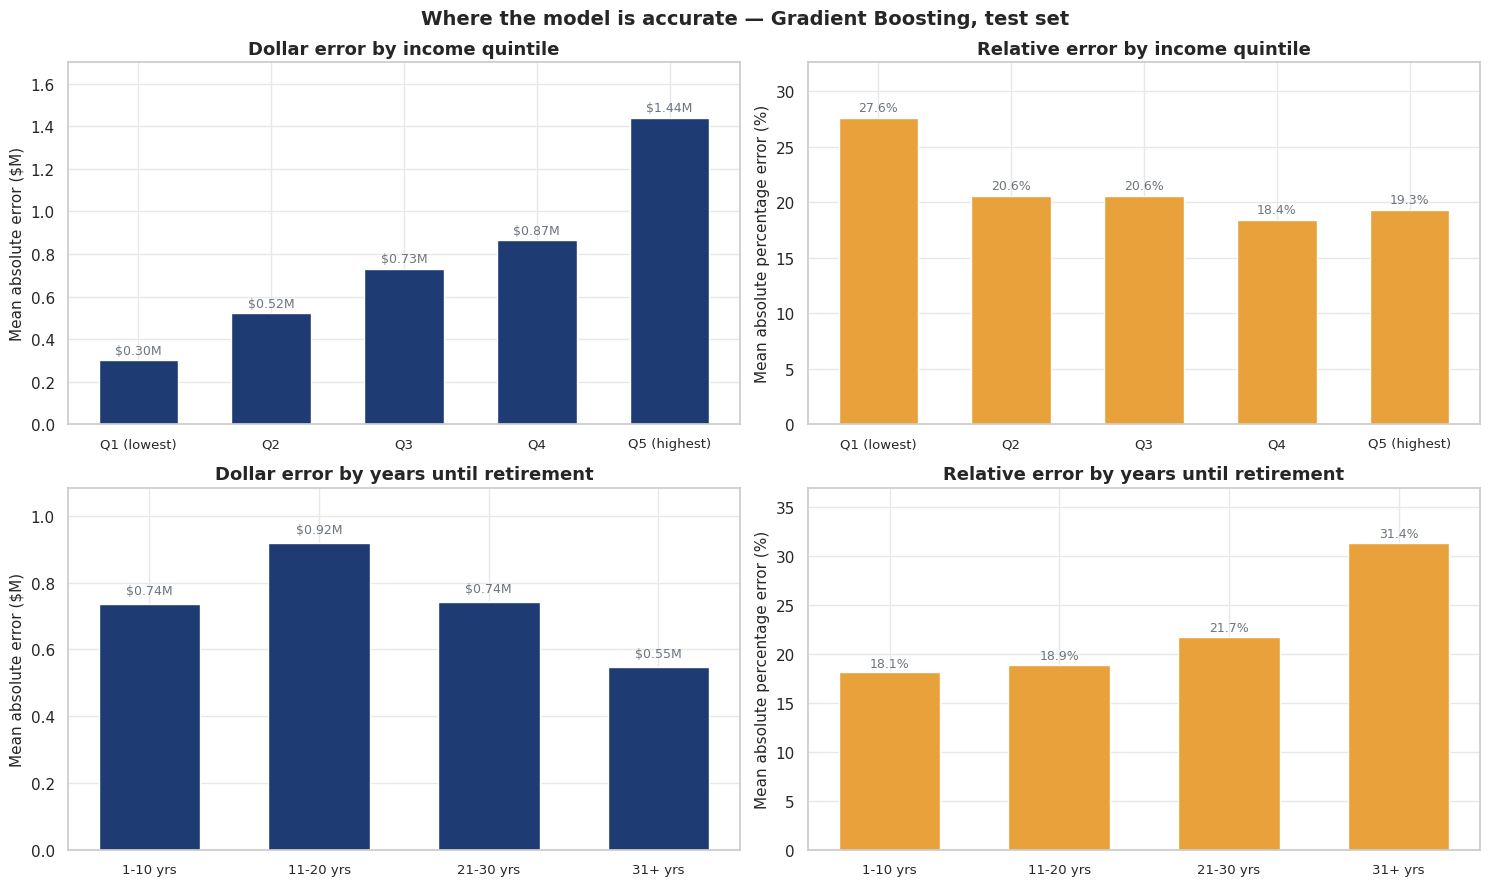

In [23]:
# --- Figure: does accuracy hold across economically meaningful groups? ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for row, (summary, label) in enumerate([(income_errors, "Income quintile"),
                                        (horizon_errors, "Years until retirement")]):
    positions = np.arange(len(summary))

    axes[row, 0].bar(positions, summary.MAE / 1e6, color=NAVY, edgecolor="white", width=0.6)
    axes[row, 0].set_xticks(positions)
    axes[row, 0].set_xticklabels(summary.index, fontsize=9.5)
    axes[row, 0].set_ylabel("Mean absolute error ($M)")
    axes[row, 0].set_title(f"Dollar error by {label.lower()}")
    for position, value in zip(positions, summary.MAE / 1e6):
        axes[row, 0].text(position, value + 0.03, f"${value:.2f}M", ha="center",
                          fontsize=9, color=SLATE)
    axes[row, 0].set_ylim(0, summary.MAE.max() / 1e6 * 1.18)

    axes[row, 1].bar(positions, summary.MAPE, color=AMBER, edgecolor="white", width=0.6)
    axes[row, 1].set_xticks(positions)
    axes[row, 1].set_xticklabels(summary.index, fontsize=9.5)
    axes[row, 1].set_ylabel("Mean absolute percentage error (%)")
    axes[row, 1].set_title(f"Relative error by {label.lower()}")
    for position, value in zip(positions, summary.MAPE):
        axes[row, 1].text(position, value + 0.6, f"{value:.1f}%", ha="center",
                          fontsize=9, color=SLATE)
    axes[row, 1].set_ylim(0, summary.MAPE.max() * 1.18)

fig.suptitle("Where the model is accurate — Gradient Boosting, test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_error_by_segment.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

### Result

The overall error distribution is uneven:

- **Median absolute error:** about &#36;449K
- **75th percentile absolute error:** about &#36;962K
- **Top 1% of absolute errors:** above &#36;4.7M
- **Customers within 25% relative error:** about 73%
- **Customers within 10% relative error:** about 34%
- **Median absolute percentage error:** 15.3%
- **Mean absolute percentage error:** 21.3%

By income, dollar errors increase with the size of the customer's retirement fund. Median projected funds rise from about **&#36;1.0M in Q1 to &#36;6.7M in Q5**, while median dollar error rises from about **&#36;302K to &#36;1.44M**.

Relative error shows the opposite pattern: it is about **27.6% in Q1**, compared with roughly **18–21%** in the other income quintiles.

By retirement horizon, relative error is highest for customers **31 or more years from retirement**, at about **31.4%**, compared with roughly **18–22%** for the other groups. Their dollar errors are actually smaller, at about **&#36;549K**, because their projected funds are smaller.

The direction of errors is broadly balanced, although the share of under-predictions rises from about **49% in Q1 to 57% in Q5**.

The main lesson is that the overall model score is not the whole story. The model performs differently across economically meaningful groups, especially when we look at relative rather than dollar error.

---

# 17. `Retirement_Fund_Goal` Ablation

### What are we doing?

We retrain the selected Gradient Boosting model with `Retirement_Fund_Goal` removed, while keeping everything else the same.

This is called an **ablation**: remove one input and measure how much performance changes.

### Why?

Notebook 2 kept `Retirement_Fund_Goal` as a predictor based on a business-process assumption: the goal is expected to be known before the projection is produced.

The ablation asks a narrower question:

> How much does the model's predictive performance actually depend on this variable?

The comparison uses the same split, preprocessing approach, model configuration, and metric. The test set remains untouched.


In [24]:
ablation_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE,
)
ablation_model.fit(X_fit_tree.drop(columns=["Retirement_Fund_Goal"]), y_fit)

ablation_predictions = ablation_model.predict(X_val_tree.drop(columns=["Retirement_Fund_Goal"]))
ablation_rmse = np.sqrt(mean_squared_error(np.exp(y_val), np.exp(ablation_predictions)))
full_rmse = comparison.loc["Gradient Boosting", "RMSE ($)"]

print(f"With Retirement_Fund_Goal:    ${full_rmse:>12,.0f}")
print(f"Without Retirement_Fund_Goal: ${ablation_rmse:>12,.0f}")
print(f"Difference:                    {ablation_rmse / full_rmse - 1:>12.1%}")
print(f"\nR2 with goal:    {comparison.loc['Gradient Boosting', 'R2']:.4f}")
print(f"R2 without goal: {r2_score(y_val, ablation_predictions):.4f}")

With Retirement_Fund_Goal:    $   1,245,172
Without Retirement_Fund_Goal: $   1,251,142
Difference:                            0.5%

R2 with goal:    0.8877
R2 without goal: 0.8884


### Result

Removing `Retirement_Fund_Goal` changes dollar RMSE by only about **0.5%** and slightly improves log-space R².

So, in this dataset, the model has **little predictive dependence on the goal variable**.

This does not prove that the variable is always safe to use. The separate business-process question — whether the goal would actually be recorded before a prediction is made — cannot be answered by predictive performance alone.

The practical conclusion is narrower: including or excluding this variable makes very little difference to accuracy in this baseline experiment.

---

# 18. What the Baseline Model Tells Us

### The model going forward

Gradient Boosting is the strongest baseline model.

| Criterion | Result |
|---|---|
| Cross-validated RMSE | &#36;1.24M, best of the three candidates |
| Fold-to-fold variation | &#36;48K standard deviation |
| Validation / CV / test RMSE | &#36;1.25M / &#36;1.24M / &#36;1.27M |
| Improvement over median baseline | 61% lower RMSE |
| Improvement over best linear model | 31% lower RMSE |
| Configuration | 300 trees, depth 3 |

The choice is not close. The four linear models are within about 0.7% of one another, while Gradient Boosting is substantially better.

Random Forest remains useful as a secondary non-linear reference because it performs reasonably close to Gradient Boosting.

### What did we learn?

**Linear models capture meaningful signal, but they do not capture the full shape of the problem.**

Ordinary Linear Regression reaches R² of about 0.776 and reduces baseline error substantially. Ridge, Lasso, and Elastic Net remain almost tied with it.

**Regularization was not the main improvement at the settings tested.**

Lasso removed 7 of 40 features, but predictive performance barely changed. This tells us that simplifying the linear model is possible without much loss, but it does not solve the limitation of linear relationships.

**The EDA finding about non-linearity carries into prediction.**

The tree ensembles use the same prepared features but represent relationships differently. Moving from the best linear model to Gradient Boosting reduces dollar RMSE by about 31%.

**Gradient Boosting is currently the best baseline, but it is not finished.**

Errors are larger in relative terms for some lower-value and longer-horizon customers. The log-to-dollar back-transform also creates an approximately 4% aggregate shortfall.

These are the main questions to carry into Notebook 4: can tuning improve the model, can the aggregate shortfall be reduced, and can performance improve for the groups with higher relative error?

---

# 19. Save the Baseline Model

The selected model and comparison results are saved to `artifacts/`.

The individual candidate models are not saved because they can be retrained easily, and Notebook 4 will build on the selected baseline.

The saved model is the **complete pipeline**: preprocessing, feature engineering, and Gradient Boosting together.

This matters because the saved object can later receive raw customer data and apply the same transformations before making a prediction.

The feature-engineering step depends on `src/feature_engineering.py`, so that module must remain available when the saved model is loaded.

The following verification step tests the saved artifact in a separate Python process.


In [25]:
baseline_results = comparison.copy()
baseline_results["Stage"] = "Validation split"

test_row = pd.DataFrame([test_scores]).set_index("Model")
test_row = test_row.rename(index={"Gradient Boosting (test set)": "Gradient Boosting"})
test_row["vs baseline"] = (test_row["RMSE ($)"] / baseline_rmse - 1) * 100
test_row["Stage"] = "Test set"

baseline_results = pd.concat([baseline_results, test_row])
baseline_results = baseline_results[["Stage", "R2", "RMSE (log)", "MAE (log)",
                                     "RMSE ($)", "MAE ($)", "MAPE (%)", "vs baseline"]]

results_path = ARTIFACTS_DIR / "03_baseline_model_results.csv"
baseline_results.round(6).to_csv(results_path)

model_path = ARTIFACTS_DIR / "03_baseline_model.joblib"
joblib.dump(final_model, model_path)

print(f"{results_path.name:<34} {results_path.stat().st_size / 1024:>7.1f} KB")
print(f"{model_path.name:<34} {model_path.stat().st_size / 1024:>7.1f} KB")

03_baseline_model_results.csv          0.9 KB
03_baseline_model.joblib             397.3 KB


In [26]:
# Reload the saved model in a separate Python process and compare its
# predictions with this notebook's, element by element.
expected_path = Path(tempfile.gettempdir()) / "baseline_predictions.npy"
np.save(expected_path, test_predictions_dollars)

reload_script = f"""
import sys
import joblib
import numpy as np
import pandas as pd

sys.path.insert(0, ".")

# joblib needs this module importable to rebuild the pipeline's
# feature-engineering step; importing it here makes that dependency explicit.
from src.feature_engineering import add_engineered_features

model = joblib.load("artifacts/03_baseline_model.joblib")
raw_records = pd.read_csv("artifacts/X_test.csv.gz", index_col=0)
predictions = np.exp(model.predict(raw_records))

expected = np.load(r"{expected_path}")
print(len(predictions))
print(np.array_equal(predictions, expected))
print(np.abs(predictions - expected).max())
"""

reload_result = subprocess.run(
    [sys.executable, "-c", reload_script],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
expected_path.unlink()

if reload_result.returncode != 0:
    raise RuntimeError(f"Reload failed:\n{reload_result.stderr}")

reloaded_count, identical, largest_difference = reload_result.stdout.strip().split("\n")

print(f"Records predicted in the fresh process: {int(reloaded_count):,}")
print(f"Identical to this notebook:             {identical}")
print(f"Largest difference ($):                 {float(largest_difference):.10f}")

assert int(reloaded_count) == len(y_test)
assert identical == "True"

Records predicted in the fresh process: 5,970
Identical to this notebook:             True
Largest difference ($):                 0.0000000000


# 20. Final Verification

This section performs the final quality checks before the baseline is treated as a reliable project artifact.

The checks confirm that:

- the transformed data has the expected shape and feature names
- missing and infinite values have been handled
- the preprocessing was learned from the appropriate training data
- the saved pipeline can be loaded successfully
- the reloaded pipeline produces the same predictions as the original pipeline

A successful reload is important because the model eventually needs to work outside the notebook. Reproducibility is part of the model, not an optional extra.


In [27]:
# The imputer inside the loaded pipeline should hold the training medians and
# nothing else: direct evidence that the test set never reached it.
fitted_imputer = preprocessor.named_transformers_["numeric"].named_steps["impute"]
numeric_columns = preprocessor.transformers_[0][2]
medians_match = np.allclose(
    fitted_imputer.statistics_,
    X_train_raw[numeric_columns].median().to_numpy(),
)

checks = [
    ("Training records unchanged from Notebook 2", len(X_train_raw) == 23880),
    ("Test records unchanged from Notebook 2", len(X_test_raw) == 5970),
    ("Feature count is 40", X_train_scaled.shape[1] == 40),
    ("Train and test features aligned",
     list(X_train_scaled.columns) == list(X_test_scaled.columns)),
    ("No missing values after preprocessing",
     int(X_train_scaled.isna().sum().sum() + X_test_scaled.isna().sum().sum()) == 0),
    ("No infinite values after preprocessing",
     bool(np.isfinite(X_train_scaled.to_numpy()).all()
          and np.isfinite(X_test_scaled.to_numpy()).all())),
    ("Preprocessing statistics come from the training data", medians_match),
    ("Validation split came from training data only",
     X_val_scaled.index.isin(X_train_raw.index).all()),
    ("Cross-validation used training data only",
     len(X_train_raw) == len(y_train)),
    ("Comparison table holds all seven models", len(comparison) == 7),
    ("Selected model is a fitted pipeline",
     hasattr(final_model.named_steps["model"], "estimators_")),
    ("Test metrics are finite",
     bool(np.isfinite(list(test_scores.values())[1:]).all())),
    ("Results file saved", results_path.exists()),
    ("Model file saved", model_path.exists()),
    ("Saved model reloads and reproduces predictions", identical == "True"),
    ("Figures saved", len(list(FIGURES_DIR.glob("03_*.png"))) == 4),
]

verification = pd.DataFrame(checks, columns=["check", "passed"]).set_index("check")
print(verification.to_string())

assert verification.passed.all(), "One or more baseline modeling checks failed."
print("\nAll baseline modeling checks passed.")

                                                      passed
check                                                       
Training records unchanged from Notebook 2              True
Test records unchanged from Notebook 2                  True
Feature count is 40                                     True
Train and test features aligned                         True
No missing values after preprocessing                   True
No infinite values after preprocessing                  True
Preprocessing statistics come from the training data    True
Validation split came from training data only           True
Cross-validation used training data only                True
Comparison table holds all seven models                 True
Selected model is a fitted pipeline                     True
Test metrics are finite                                 True
Results file saved                                      True
Model file saved                                        True
Saved model reloads and 

# 21. Next Step

### Where this leaves the project

| Question | Answer from this notebook |
|---|---|
| What worked? | Gradient Boosting was the strongest baseline, with test RMSE of about &#36;1.27M and R² of 0.896 in log space. |
| What did not? | Linear models were substantially weaker, and regularization did not materially improve them at the settings tested. |
| Did the EDA hold up? | Yes. The non-linear relationships identified in Notebook 1 are reflected in predictive performance. |
| Where does it struggle? | Some lower-value and longer-horizon customers have higher relative error. |
| What remains unresolved? | Hyperparameter tuning, the log-to-dollar back-transform gap, and whether another objective can improve business-level performance. |

### Notebook 4

Notebook 4 should start from the verified baseline rather than repeat the model comparison.

The main work is:

1. **Tune Gradient Boosting** using cross-validation on the training data. Important parameters include `learning_rate`, `n_estimators`, `max_depth`, `subsample`, and `min_samples_leaf`.
2. **Test stronger boosting implementations** if they allow a broader and more efficient search.
3. **Investigate the target scale.** Compare the current log-target approach with a dollar-scale objective and test a smearing correction for the aggregate gap measured in Section 15.
4. **Revisit feature design.** Test whether additions such as `Age²` or spline terms allow a linear model to capture more of the non-linear structure while remaining interpretable.
5. **Investigate the weaker segments** identified in Section 16 and determine whether the final model can reduce their relative error.

The test set stays sealed until Notebook 4 has a final candidate model.
